# Detecting Fraud in Mobile-Money Transfers

**Which transfers are fraudulent, how much of the fraud value can a model stop, and how many honest customers
does it freeze to do so?**

This notebook analyses 6,362,620 simulated mobile-money transactions from PaySim (Kaggle's "PaySim 1"), a
simulator built from the logs of an African mobile-money service: one row per transaction, one step per
simulated hour, over about a month. In mobile money a fraud flag freezes the customer's funds, so every false
alarm locks an honest customer out of their own money and every missed fraud is a direct loss.

**How this notebook is organised.** The analysis is driven by the three questions above, so it is organised
around them rather than around a single model:

- **Part 1, what the data can support** (sections 1 to 5): load and check the transactions, explore them,
  work through two real frauds as an accountant would, turn the ledger rule they break into features, and
  split the data by time so that every model is tested on the future. Two facts surface here that shape
  everything later: fraud occurs only in two of the five transaction types, and honest volume collapses in
  the last third of the simulation while fraud does not.
- **Part 2, which transfers are fraudulent?** (sections 6 to 13): a two-question tree a reader can follow,
  then gradient-boosted trees, measured with the metrics that work for rare events; a cut-off chosen from the
  cost of mistakes and restated at the real fraud rate; four model families compared; stability over time; a
  resampling check; and SHAP explanations of single decisions.
- **Part 3, what it is worth** (section 14): the fraud value each screen stops on the test window, and the
  honest customers it freezes to do so.
- **Part 4, limits and record** (sections 15 to 17): how the shipped pipeline in `src/` differs from this
  walkthrough, what the results cannot show, and a results file every quoted number is checked against.

Each step is one short code cell with an explanation of what it does and what its output shows. Cells
containing **Check** assertions stop the notebook at the step that went wrong instead of carrying a wrong
number forward. Boxes marked **Try it** suggest a change to rerun. PaySim is a simulator, so every score
below says more about the method than about the accuracy to expect on a real network (section 16).

---
# Part 1: What the data can support

## 1. Setup

**Step 1.1:** Import the libraries, fix the random seed so every run gives the same numbers, and set the three
settings the rest of the notebook refers to.

In [1]:
import os
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (average_precision_score, confusion_matrix, precision_recall_curve,
                             roc_auc_score, roc_curve)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RUN_STARTED = time.time()   # used for the runtime in the results file
SEED = 42                   # one seed, so every run gives the same numbers
SPLIT_STEP = 490            # train on hours 1 to 490, test on hours 491 to 743 (section 5)
COST_RATIO = 10             # a missed fraud costs as much as 10 false alarms (section 9)
N_JOBS = 1                  # threads for the boosted models; more threads use more memory, results are the same
RF_JOBS = 4                 # random forests share one copy of the data, so extra threads are cheap

np.random.seed(SEED)
pd.options.display.float_format = "{:,.2f}".format
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
os.makedirs("figs", exist_ok=True)
os.makedirs("outputs", exist_ok=True)
print("Setup OK. pandas:", pd.__version__, "| numpy:", np.__version__)

Setup OK. pandas: 3.0.3 | numpy: 2.4.6


---
## 2. Data loading

The PaySim CSV (470 MB) is not stored in the repository: download "PaySim 1" from
[Kaggle](https://www.kaggle.com/datasets/ealaxi/paysim1) and put `PS_20174392719_1491204439457_log.csv` in the
`data` folder next to this notebook.

**Step 2.1:** Load the file. PaySim's column names are inconsistently capitalised (`oldbalanceOrg`,
`newbalanceOrig`), so they are renamed to one pattern.

In [2]:
df = pd.read_csv("data/PS_20174392719_1491204439457_log.csv")

df = df.rename(columns={"oldbalanceOrg": "oldBalanceOrig", "newbalanceOrig": "newBalanceOrig",
                        "oldbalanceDest": "oldBalanceDest", "newbalanceDest": "newBalanceDest"})
print(f"{len(df):,} transactions, {df.shape[1]} columns, {df.memory_usage(deep=True).sum() / 1e9:.2f} GB in memory")
df.head()

6,362,620 transactions, 11 columns, 0.74 GB in memory


,step,type,amount,nameOrig,oldBalanceOrig,newBalanceOrig,nameDest,oldBalanceDest,newBalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,839.64",C1231006815,"170,136.00","160,296.36",M1979787155,0.00,0.00,0,0
1,1,PAYMENT,"1,864.28",C1666544295,"21,249.00","19,384.72",M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,"21,182.00",0.00,1,0
4,1,PAYMENT,"11,668.14",C2048537720,"41,554.00","29,885.86",M1230701703,0.00,0.00,0,0


In [3]:
# Check: every transaction in the file was read, once
assert len(df) == 6_362_620

Each row is one transaction:

| Column | Meaning |
|---|---|
| `step` | Hour of the simulation, 1 to 743 (about 31 days) |
| `type` | TRANSFER, CASH_OUT, PAYMENT, CASH_IN or DEBIT |
| `amount` | Value of the transaction, in the simulator's currency units |
| `nameOrig`, `nameDest` | Sender and recipient account IDs (`C` customer, `M` merchant) |
| `oldBalanceOrig`, `newBalanceOrig` | Sender's balance before and after |
| `oldBalanceDest`, `newBalanceDest` | Recipient's balance before and after |
| `isFraud` | 1 if the transaction was fraud: the label to predict |
| `isFlaggedFraud` | 1 if PaySim's own built-in rule flagged it |

### 2.1 Data-quality checks

**Step 2.2:** Look for missing values, duplicated rows, impossible amounts and balances, and gaps in the hour
sequence.

In [4]:
balance_cols = ["oldBalanceOrig", "newBalanceOrig", "oldBalanceDest", "newBalanceDest"]
print("missing values:", int(df.isna().sum().sum()))
print(f"fully duplicated rows: {df.duplicated().sum():,}")
print(f"amount <= 0: {(df['amount'] <= 0).sum():,}  (of which fraud: {((df['amount'] <= 0) & (df['isFraud'] == 1)).sum():,})")
print(f"negative balances: {(df[balance_cols] < 0).any(axis=1).sum():,}")
print(f"hours: {df['step'].min()} to {df['step'].max()}, {df['step'].nunique()} distinct")

missing values: 0


fully duplicated rows: 0


amount <= 0: 16  (of which fraud: 16)
negative balances: 0


hours: 1 to 743, 743 distinct


In [5]:
# Check: nothing missing, no negative balances, and every hour of the month is present
assert df.isna().sum().sum() == 0
assert (df[balance_cols] >= 0).all().all()
assert df["step"].nunique() == 743 and df["step"].min() == 1

The file is clean in the usual sense: nothing missing, no duplicates, no negative balances, all 743 hours
present. The 16 transactions with an amount of zero are all fraud: attempted transfers of nothing, which the
model will see as fraud with no money behind it. They are kept, because they are labelled, and section 14
counts fraud by value, where they weigh nothing.

**Step 2.3:** Look closely at two fraudulent transactions, rows 2 and 3, before any statistics.

In [6]:
df.loc[[2, 3], ["type", "amount", "oldBalanceOrig", "newBalanceOrig", "oldBalanceDest", "newBalanceDest", "isFraud"]]

,type,amount,oldBalanceOrig,newBalanceOrig,oldBalanceDest,newBalanceDest,isFraud
2,TRANSFER,181.00,181.00,0.00,0.00,0.00,1
3,CASH_OUT,181.00,181.00,0.00,"21,182.00",0.00,1


Work through them as an accountant would:

- **Row 2, a TRANSFER of 181.** The sender had 181 and ends with 0, so the whole balance left. But the recipient
  had 0 and still has 0: 181 left one account and arrived nowhere.
- **Row 3, a CASH_OUT of 181.** The sender again goes from 181 to 0. The recipient had 21,182 and ends with 0,
  so the recipient's balance *fell* while receiving money.

In an honest transaction the sender's balance falls by exactly the amount and the recipient's rises by exactly
the amount. Both frauds break that rule. Keep these two rows in mind; section 4 turns the observation into
something a model can use.

---
## 3. Exploratory data analysis

### 3.1 Transaction types

**Step 3.1:** Count the transactions and the money moved by type, and count the frauds in each.

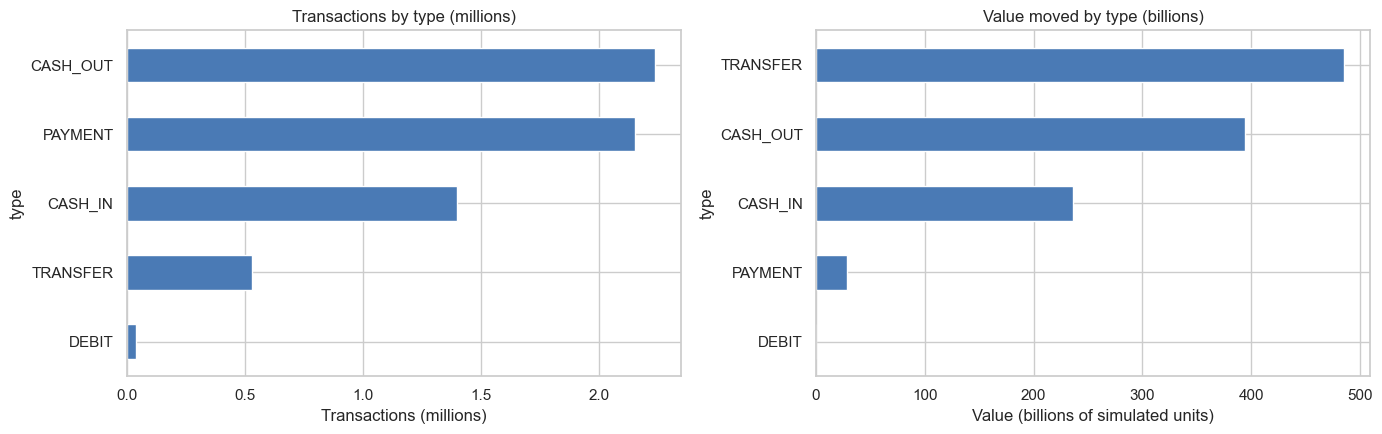

,transactions,value,median_amount,frauds,fraud_rate
type,,,,,
CASH_OUT,2237500,"394,412,995,224.49","147,072.18",4116,0.00
TRANSFER,532909,"485,291,987,263.17","486,308.39",4097,0.01
CASH_IN,1399284,"236,367,391,912.46","143,427.71",0,0.00
DEBIT,41432,"227,199,221.28","3,048.99",0,0.00
PAYMENT,2151495,"28,093,371,138.37","9,482.19",0,0.00


In [7]:
by_type = df.groupby("type").agg(transactions=("amount", "size"), value=("amount", "sum"),
                                 median_amount=("amount", "median"), frauds=("isFraud", "sum"))
by_type["fraud_rate"] = by_type["frauds"] / by_type["transactions"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
(by_type["transactions"] / 1e6).sort_values().plot(kind="barh", ax=axes[0], color="#4a7ab5")
axes[0].set_title("Transactions by type (millions)")
axes[0].set_xlabel("Transactions (millions)")
(by_type["value"] / 1e9).sort_values().plot(kind="barh", ax=axes[1], color="#4a7ab5")
axes[1].set_title("Value moved by type (billions)")
axes[1].set_xlabel("Value (billions of simulated units)")
plt.tight_layout()
plt.savefig("figs/transactions_by_type.png", dpi=150, bbox_inches="tight")
plt.show()
by_type.sort_values("frauds", ascending=False)

In [8]:
# Check: fraud occurs only in TRANSFER and CASH_OUT
assert by_type.loc[["CASH_IN", "DEBIT", "PAYMENT"], "frauds"].sum() == 0

CASH_OUT and PAYMENT are the most common types, but TRANSFER moves the most money: its median transaction is
about three times a CASH_OUT. Fraud appears only in TRANSFER and CASH_OUT, split almost evenly between them: in
PaySim a fraud transfers money out of a victim's account and then cashes it out. The other three types contain
no fraud at all, so section 4 sets them aside.

### 3.2 How rare fraud is, and why accuracy misleads

**Step 3.2:** Count the frauds.

In [9]:
n_fraud = int(df["isFraud"].sum())
print(f"frauds: {n_fraud:,} of {len(df):,} transactions ({n_fraud / len(df):.4%}), "
      f"worth {df.loc[df['isFraud'] == 1, 'amount'].sum() / 1e9:.1f} billion")

frauds: 8,213 of 6,362,620 transactions (0.1291%), worth 12.1 billion


About 1 transaction in 775 is fraud. Now consider the laziest possible "model": it says *not fraud* for every
transaction.

**Step 3.3:** Score that lazy model.

In [10]:
lazy_prediction = np.zeros(len(df), dtype=int)          # never flags anything
accuracy = (lazy_prediction == df["isFraud"]).mean()
frauds_caught = int(((lazy_prediction == 1) & (df["isFraud"] == 1)).sum())
print(f"accuracy: {accuracy:.2%}   frauds caught: {frauds_caught}")

accuracy: 99.87%   frauds caught: 0


99.87% accurate, and it catches nothing. So accuracy is the wrong yardstick for rare events. Two measures are
used instead, both about the fraud class only:

- **Recall** = frauds caught / all frauds. *Of the real fraud, how much was caught?*
- **Precision** = frauds caught / all transactions flagged. *When an alarm is raised, how often is it real?*

If a model flags 100 transactions, 90 of them are fraud, and there were 120 frauds in total, then precision is
90/100 = 90% and recall is 90/120 = 75%. The lazy model has a recall of 0, which is the number that exposes it.

### 3.3 Amounts

**Step 3.4:** Compare the amounts of fraudulent and honest TRANSFER and CASH_OUT transactions, on a log scale
because the amounts span seven orders of magnitude.

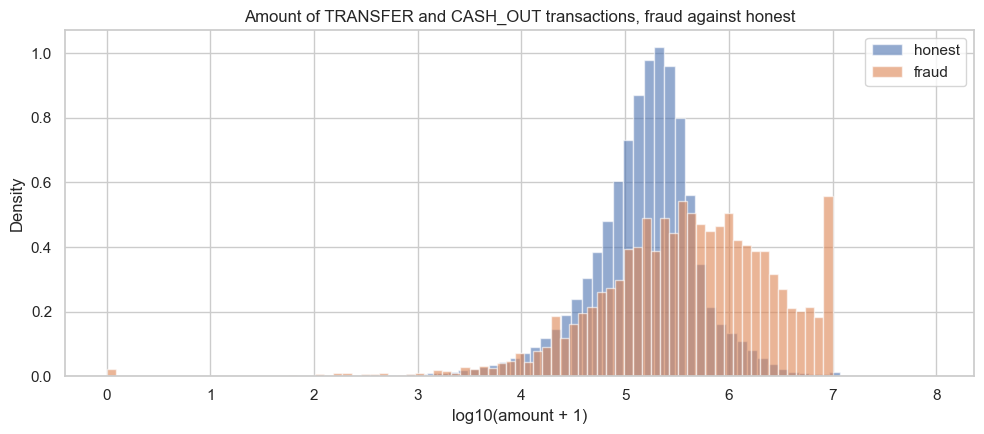

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,"2,762,196.00","314,115.50","877,144.15",0.01,"82,908.23","171,034.46","305,994.18","92,445,516.64"
1,"8,213.00","1,467,967.30","2,404,252.95",0.00,"127,091.33","441,423.44","1,517,771.48","10,000,000.00"


In [11]:
active_types = df["type"].isin(["TRANSFER", "CASH_OUT"])
log_amount = np.log10(df.loc[active_types, "amount"] + 1)
is_fraud = df.loc[active_types, "isFraud"] == 1

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(log_amount[~is_fraud], bins=80, density=True, alpha=0.6, label="honest")
ax.hist(log_amount[is_fraud], bins=80, density=True, alpha=0.6, label="fraud")
ax.set_title("Amount of TRANSFER and CASH_OUT transactions, fraud against honest")
ax.set_xlabel("log10(amount + 1)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.savefig("figs/amount_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
df.loc[active_types].groupby("isFraud")["amount"].describe()

Fraudulent transfers are larger on average (a median of about 441,000 against 171,000) but the two
distributions overlap heavily, so the amount alone cannot separate them. The fraud distribution stops dead at
10,000,000: the simulator caps a single fraudulent transfer there, and 287 frauds sit exactly on the cap.

### 3.4 Over time

**Step 3.5:** Plot transactions and frauds per simulated day.

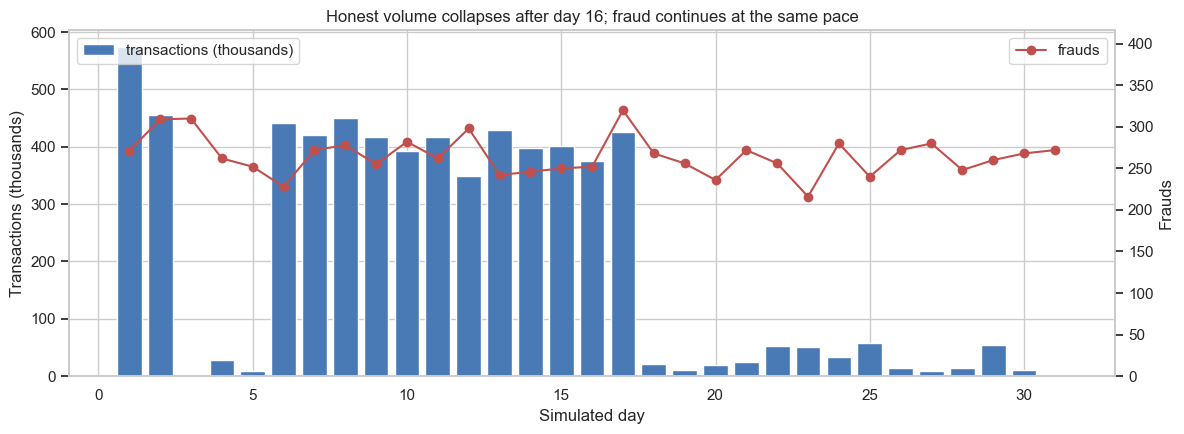

transactions per hour, hours 1-490: 12,336; after: 1,257


frauds per hour, hours 1-490: 11.1; after: 10.9


In [12]:
day = (df["step"] - 1) // 24 + 1
per_day = df.groupby(day).agg(transactions=("amount", "size"), frauds=("isFraud", "sum"))

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(per_day.index, per_day["transactions"] / 1e3, color="#4a7ab5", label="transactions (thousands)")
ax.set_xlabel("Simulated day")
ax.set_ylabel("Transactions (thousands)")
ax2 = ax.twinx()
ax2.plot(per_day.index, per_day["frauds"], color="#c0504d", marker="o", label="frauds")
ax2.set_ylabel("Frauds")
ax2.set_ylim(0, per_day["frauds"].max() * 1.3)
ax2.grid(False)
ax.set_title("Honest volume collapses after day 16; fraud continues at the same pace")
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.savefig("figs/volume_over_time.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"transactions per hour, hours 1-{SPLIT_STEP}: {df[df['step'] <= SPLIT_STEP].groupby('step').size().mean():,.0f}; "
      f"after: {df[df['step'] > SPLIT_STEP].groupby('step').size().mean():,.0f}")
print(f"frauds per hour, hours 1-{SPLIT_STEP}: {df[df['step'] <= SPLIT_STEP].groupby('step')['isFraud'].sum().mean():.1f}; "
      f"after: {df[df['step'] > SPLIT_STEP].groupby('step')['isFraud'].sum().mean():.1f}")

Honest volume runs at about 400,000 transactions a day for most of the first 17 days (days 3 to 5 are
near-empty), then falls to a few tens of thousands, and the last day holds a few hundred transactions. Fraud runs at about 11 an hour throughout. That is why the
test window in section 5 has ten times the fraud rate of the training window: not more fraud, but far fewer
honest transactions around it.

**Step 3.6:** Plot the fraud rate among TRANSFER and CASH_OUT transactions by hour of the day.

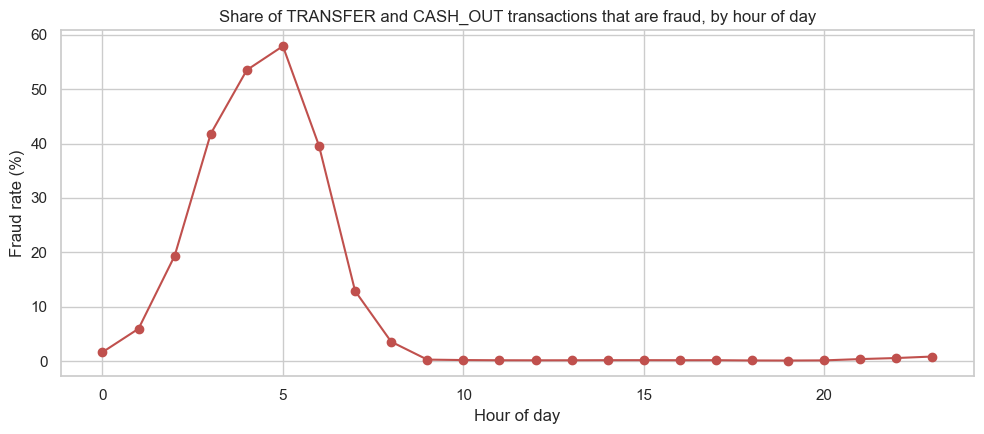

In [13]:
hour = df.loc[active_types, "step"] % 24
by_hour = is_fraud.groupby(hour).mean() * 100
fig, ax = plt.subplots(figsize=(10, 4.5))
by_hour.plot(marker="o", color="#c0504d", ax=ax)
ax.set_title("Share of TRANSFER and CASH_OUT transactions that are fraud, by hour of day")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Fraud rate (%)")
plt.tight_layout()
plt.savefig("figs/fraud_rate_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()

The rate jumps in the early hours: at 4 and 5 in the morning more than half of these transactions are
fraud. Fraud keeps going around the clock while honest activity drops off at night, so a larger share of what
happens at 5 a.m. is fraud. The hour of day is therefore kept as a model input in section 4.

### 3.5 Accounts

**Step 3.7:** Who sends and who receives? Account IDs start with `C` for a customer and `M` for a merchant.
Check which types go to merchants, whether fraud recipients reappear, and how often a sender appears more than
once.

In [14]:
to_merchant = df["nameDest"].str.startswith("M")
fraud_rows = df["isFraud"] == 1
print("share of transactions paid to a merchant, by type:")
print((to_merchant.groupby(df["type"]).mean() * 100).round(1).to_string())
print(f"\nfrauds paid to a merchant: {int(to_merchant[fraud_rows].sum())}")
print(f"distinct senders: {df['nameOrig'].nunique():,} of {len(df):,} transactions; "
      f"senders seen more than once: {(df['nameOrig'].value_counts() > 1).sum():,}")
print(f"fraud recipients that appear as a sender anywhere in the data: {df.loc[fraud_rows, 'nameDest'].isin(df['nameOrig']).sum()} of {n_fraud:,}")
print(f"fraud recipients that receive more than one fraud: {(df.loc[fraud_rows, 'nameDest'].value_counts() > 1).sum()}")

share of transactions paid to a merchant, by type:


type
CASH_IN      0.00
CASH_OUT     0.00
DEBIT        0.00
PAYMENT    100.00
TRANSFER     0.00

frauds paid to a merchant: 0


distinct senders: 6,353,307 of 6,362,620 transactions; senders seen more than once: 9,298


fraud recipients that appear as a sender anywhere in the data: 18 of 8,213
fraud recipients that receive more than one fraud: 44


Only PAYMENT goes to merchants, and no fraud does. Almost every sender appears exactly once, and the accounts
that receive fraud almost never send anything or receive a second fraud. So the account IDs carry no pattern a
model could learn from this data (a real network would be different: repeat mule accounts are a strong signal),
and section 4 drops them.

### 3.6 The built-in flag

**Step 3.8:** Before building anything, check the detector PaySim already provides, `isFlaggedFraud`. Any
model built here must beat it.

In [15]:
flagged = df["isFlaggedFraud"] == 1
caught = int((flagged & fraud_rows).sum())
print(f"transactions flagged: {int(flagged.sum())}   frauds among them: {caught}")
print(f"recall of the built-in flag: {caught / n_fraud:.2%}")

transactions flagged: 16   frauds among them: 16
recall of the built-in flag: 0.19%


The built-in rule flags 16 transactions and catches about 0.2% of the fraud. It is not a usable detector; it
is kept only as the yardstick in section 14 and dropped from the model inputs.

### 3.7 Balances

**Step 3.9:** How often does a balance read 0 before *and* after a non-zero transaction? That is almost
certainly "not recorded" rather than a real zero. Compare fraud and honest transactions on both sides of the
ledger, and check the one pattern rows 2 and 3 share: the amount equals the sender's whole balance.

In [16]:
active = df[active_types]
sender_zero_pair = (active["oldBalanceOrig"] == 0) & (active["newBalanceOrig"] == 0) & (active["amount"] > 0)
recipient_zero_pair = (active["oldBalanceDest"] == 0) & (active["newBalanceDest"] == 0) & (active["amount"] > 0)
whole_balance = active["oldBalanceOrig"] == active["amount"]
fraud_active = active["isFraud"] == 1

balance_patterns = pd.DataFrame({
    "fraud": [sender_zero_pair[fraud_active].mean(), recipient_zero_pair[fraud_active].mean(), whole_balance[fraud_active].mean()],
    "honest": [sender_zero_pair[~fraud_active].mean(), recipient_zero_pair[~fraud_active].mean(), whole_balance[~fraud_active].mean()],
}, index=["sender balance 0 -> 0", "recipient balance 0 -> 0", "amount equals the sender's whole balance"])
(balance_patterns * 100).round(2)

,fraud,honest
sender balance 0 -> 0,0.30,47.37
recipient balance 0 -> 0,49.56,0.06
amount equals the sender's whole balance,97.82,0.00


Three facts, all read off the balances alone:

- **The recipient's balance is unrecorded for half of all frauds** (0 before and after a non-zero transfer),
  against well under 1% of honest transactions. Section 4 marks that pattern rather than filling it in.
- **The sender's balance is unrecorded for half of all honest transfers.** This is a quirk of the simulator,
  and it means "the sender's balance went to zero" is not, on its own, a fraud signal: it is true of 90% of
  honest transfers too.
- **Almost every fraud takes the sender's whole balance**, to the unit, and no honest transaction does. That is
  the signature PaySim's fraud generator leaves, and section 13 shows the model finding it.

---
## 4. Feature engineering: the ledger rule

Back to rows 2 and 3. The rule they broke can be written as two numbers that should be zero for an honest
transaction:

- `errorBalanceOrig` = new sender balance + amount - old sender balance
- `errorBalanceDest` = old recipient balance + amount - new recipient balance

**Step 4.1:** Keep TRANSFER and CASH_OUT, separate the label from the inputs, turn the type into a number and
add the hour of day. The account IDs are dropped (section 3.5) and the built-in flag is dropped (section 3.6);
it is kept aside only for the comparison in section 14.

In [17]:
target = active["isFraud"]                                                       # what is predicted
builtin_flag = active["isFlaggedFraud"]                                          # kept aside for section 14
features = active.drop(columns=["isFraud", "isFlaggedFraud", "nameOrig", "nameDest"]).copy()
features["type"] = features["type"].map({"TRANSFER": 0, "CASH_OUT": 1}).astype("int8")
features["hour"] = (features["step"] % 24).astype("int8")                        # hour of the day, 0-23

print(f"kept {len(active):,} of {len(df):,} transactions, and all {int(target.sum()):,} frauds")
del df, active

kept 2,770,409 of 6,362,620 transactions, and all 8,213 frauds


In [18]:
# Check: filtering removed transactions but not a single fraud
assert int(target.sum()) == n_fraud

**Step 4.2:** Mark the unrecorded recipient balances (section 3.7) with -1, a value that cannot occur
naturally, instead of filling them in. The same 0 -> 0 pattern on the sender's side is treated as unknown
(`NaN`); tree models handle missing values directly.

In [19]:
features.loc[recipient_zero_pair, ["oldBalanceDest", "newBalanceDest"]] = -1
features.loc[sender_zero_pair, ["oldBalanceOrig", "newBalanceOrig"]] = np.nan
print(f"recipient balances marked -1: {int(recipient_zero_pair.sum()):,}   sender balances set to NaN: {int(sender_zero_pair.sum()):,}")

recipient balances marked -1: 5,776   sender balances set to NaN: 1,308,566


**Step 4.3:** Compute the two error features and read them off rows 2 and 3.

In [20]:
features["errorBalanceOrig"] = features["newBalanceOrig"] + features["amount"] - features["oldBalanceOrig"]
features["errorBalanceDest"] = features["oldBalanceDest"] + features["amount"] - features["newBalanceDest"]
features.loc[[2, 3], ["amount", "errorBalanceOrig", "errorBalanceDest"]]

,amount,errorBalanceOrig,errorBalanceDest
2,181.00,0.00,181.00
3,181.00,0.00,"21,363.00"


For the two frauds the sender-side error is 0 (the sender's balance fell by exactly 181), but the recipient
side is off: by 181 for row 2 (the money arrived nowhere; the -1 marker cancels out in the subtraction) and by
21,363 for row 3 (21,182 + 181 should have been there, and 0 is).

**Step 4.4:** Does that pattern hold across all transactions? Compare the recipient error for fraud and honest
transactions, next to the raw amount.

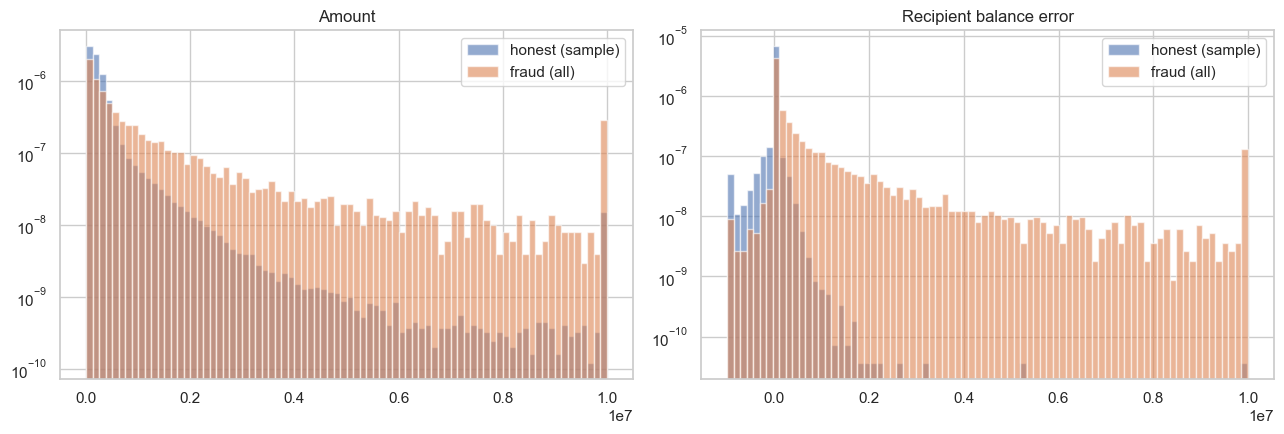

sender error exactly 0:    fraud 99.5%, honest 9.2%
recipient error exactly 0: fraud 40.6%, honest 71.2%


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sample = features.sample(200_000, random_state=SEED).index.union(features.index[target == 1])
for ax, col, title in [(axes[0], "amount", "Amount"), (axes[1], "errorBalanceDest", "Recipient balance error")]:
    values = features.loc[sample, col].clip(lower=-1e6, upper=1e7)
    ax.hist(values[target[sample] == 0], bins=80, alpha=0.6, density=True, label="honest (sample)")
    ax.hist(values[target[sample] == 1], bins=80, alpha=0.6, density=True, label="fraud (all)")
    ax.set_title(title)
    ax.set_yscale("log")
    ax.legend()
plt.tight_layout()
plt.savefig("figs/error_feature_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"sender error exactly 0:    fraud {(features.loc[target == 1, 'errorBalanceOrig'].abs() < 1e-6).mean():.1%}, "
      f"honest {(features.loc[target == 0, 'errorBalanceOrig'].abs() < 1e-6).mean():.1%}")
print(f"recipient error exactly 0: fraud {(features.loc[target == 1, 'errorBalanceDest'].abs() < 1e-6).mean():.1%}, "
      f"honest {(features.loc[target == 0, 'errorBalanceDest'].abs() < 1e-6).mean():.1%}")

The amounts overlap; the recipient error does not. The two print lines add a twist: for fraud the *sender's*
side of the ledger is exact in 99% of cases, while for honest transactions it is exact in only 9%, mostly
because of the unrecorded sender balances in section 3.7. So "the sender's ledger is clean and the recipient's
is not" is the combination that marks a fraud, and section 6 shows a two-question tree finding exactly that.

**Step 4.5:** Look at the whole balance block at once. The correlation between the balance fields and the
amount is the fingerprint of the ledger rule: in an honest transaction the sender's new balance tracks the old
one and the recipient's new balance rises with the amount. Draw the correlations for honest and for fraudulent
transactions side by side.

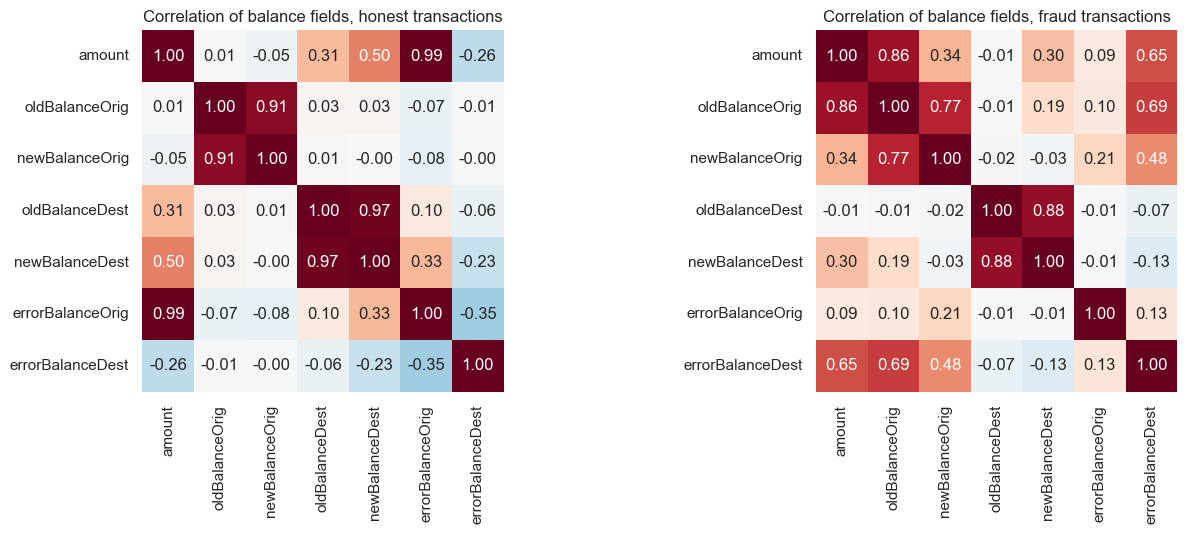

In [22]:
block = ["amount", "oldBalanceOrig", "newBalanceOrig", "oldBalanceDest", "newBalanceDest", "errorBalanceOrig", "errorBalanceDest"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, label, mask in [(axes[0], "honest", target == 0), (axes[1], "fraud", target == 1)]:
    sns.heatmap(features.loc[mask, block].corr(), vmin=-1, vmax=1, cmap="RdBu_r", annot=True, fmt=".2f",
                square=True, cbar=False, ax=ax)
    ax.set_title(f"Correlation of balance fields, {label} transactions")
plt.tight_layout()
plt.savefig("figs/balance_fingerprint.png", dpi=150, bbox_inches="tight")
plt.show()

The two fingerprints differ. In honest transactions the amount moves with the recipient's new balance
(0.50) and barely with the sender's old balance (0.00); in fraud the amount moves with the sender's old balance
(0.86), because a fraud takes what the account holds, and with the recipient error (0.65), because what was
taken does not arrive.

### 4.1 The leakage check

`isFlaggedFraud` is PaySim's own verdict on the transaction, `step` identifies the hour and so the period a
transaction belongs to, and the account IDs are unique labels. None of them is something a model should learn
from: the first is an answer, the second would let the model memorise the test period, and the third cannot
generalise. The guard below is run, not just described: a leaked column does not break a model, it improves
the score, so nothing downstream would flag it.

**Step 4.6:** Fix the model inputs and run the guard.

In [23]:
LEAKY_COLUMNS = ["isFraud", "isFlaggedFraud", "nameOrig", "nameDest", "step"]
MODEL_COLS = [c for c in features.columns if c != "step"]

leaked = [c for c in MODEL_COLS if c in LEAKY_COLUMNS]
assert not leaked, f"leaked columns reached the model inputs: {leaked}"
print("model inputs:", MODEL_COLS)
print("leakage guard passed: none of", LEAKY_COLUMNS, "is a model input")

model inputs: ['type', 'amount', 'oldBalanceOrig', 'newBalanceOrig', 'oldBalanceDest', 'newBalanceDest', 'hour', 'errorBalanceOrig', 'errorBalanceDest']
leakage guard passed: none of ['isFraud', 'isFlaggedFraud', 'nameOrig', 'nameDest', 'step'] is a model input


---
## 5. Split by time: test on the future

A model is always used on transactions that happen *after* it was trained. If the rows were shuffled and split
at random, the model would train on hour 700 and be tested on hour 300, and its score would be better than
anything it could achieve in use. So the split is by time:

```
hour 1 ............................ 490 | 491 ................ 743
              training (fit the model)  |  test (score it once)
```

`step` itself is left out of the inputs (section 4.1): every test hour is later than every training hour, so
the model could never have learned what to do with it. `hour` (0 to 23) repeats every day, so it stays.

**Step 5.1:** Split.

In [24]:
train_mask = features["step"] <= SPLIT_STEP

X_train, y_train = features.loc[train_mask, MODEL_COLS], target[train_mask]
X_test, y_test = features.loc[~train_mask, MODEL_COLS], target[~train_mask]

print(f"training: {len(X_train):>9,} transactions, fraud rate {y_train.mean():.2%}, {int(y_train.sum()):,} frauds")
print(f"test:     {len(X_test):>9,} transactions, fraud rate {y_test.mean():.2%}, {int(y_test.sum()):,} frauds")

training: 2,638,273 transactions, fraud rate 0.21%, 5,459 frauds
test:       132,136 transactions, fraud rate 2.08%, 2,754 frauds


In [25]:
# Check: every training transaction happened before every test transaction, and nothing was lost
assert features.loc[train_mask, "step"].max() < features.loc[~train_mask, "step"].min()
assert len(X_train) + len(X_test) == len(features)

The test window has about ten times the fraud rate of the training window, for the reason section 3.4 showed:
fraud continues at the same pace while honest volume falls away in the last days of the simulation. Section 9
works out what that does to precision, and section 11 checks whether a model trained on the busy period holds
up in the quiet one.

---
# Part 2: Which transfers are fraudulent?

## 6. A first model you can read

Before reaching for a powerful model, train one small enough to read: a decision tree that may ask only two
questions, about the two error features.

**Step 6.1:** Train the tree and print its rules.

In [26]:
from sklearn.tree import DecisionTreeClassifier, export_text

tree_cols = ["errorBalanceOrig", "errorBalanceDest"]
tree = DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=SEED)
tree.fit(X_train[tree_cols].fillna(0), y_train)
print(export_text(tree, feature_names=tree_cols))

|--- errorBalanceDest <= 61.52
|   |--- errorBalanceOrig <= 0.00
|   |   |--- class: 0
|   |--- errorBalanceOrig >  0.00
|   |   |--- class: 0
|--- errorBalanceDest >  61.52
|   |--- errorBalanceOrig <= 0.01
|   |   |--- class: 1
|   |--- errorBalanceOrig >  0.01
|   |   |--- class: 0



Read the rules from the top. The tree calls a transaction fraud when the recipient's balance is short by more
than about 62 *and* the sender's balance moved by exactly the amount (`errorBalanceOrig` close to 0). In words:
the sender's side of the ledger is clean, but the money never properly arrived. That is row 2 and row 3, and
the combination section 4 pointed at.

`class_weight="balanced"` tells the tree to treat the rare frauds as seriously as the many honest transactions;
without it, the tree would do best by calling everything honest, exactly like the lazy model of section 3.2.

**Step 6.2:** Score the tree on the test window with a confusion matrix: a count of every combination of truth
and prediction.

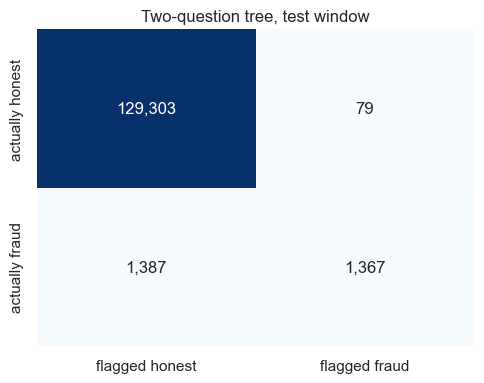

recall:    49.6%   precision: 94.5%


In [27]:
def show_confusion(truth, flags, title):
    cm = confusion_matrix(truth, flags)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["flagged honest", "flagged fraud"], yticklabels=["actually honest", "actually fraud"])
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    print(f"recall:    {cm[1, 1] / cm[1].sum():.1%}   precision: {cm[1, 1] / max(cm[:, 1].sum(), 1):.1%}")
    return cm


tree_flags = tree.predict(X_test[tree_cols].fillna(0))
tree_cm = show_confusion(y_test, tree_flags, "Two-question tree, test window")

Two questions catch about half the test fraud, and roughly 19 out of 20 alarms are real. That is already far
beyond the built-in flag. The frauds it misses are the ones that need more than two questions.

> **Try it:** change `max_depth=2` to `max_depth=4` and rerun Steps 6.1 and 6.2. How do recall and precision
> move, and how much harder are the rules to read?

---
## 7. Measuring a detector properly

The tree gave one recall and one precision, at one cut-off. Most models output a **score** between 0 and 1,
and the cut-off is a choice. Lower it and more fraud is caught (recall up) but more false alarms are raised
(precision down). A **precision-recall curve** shows every cut-off at once, and **PR-AUC** (also called average
precision) summarises the curve in one number between 0 and 1. A model that guesses at random scores about the
fraud rate of the test set, here about 0.02.

**Step 7.1:** Write one scoring function so every model is measured the same way: PR-AUC, ROC-AUC, and the best
recall available while keeping precision at or above 99%.

In [28]:
results = {}


def score_model(name, scores):
    precision, recall, _ = precision_recall_curve(y_test, scores)
    recall_at_99 = recall[:-1][precision[:-1] >= 0.99].max() if (precision[:-1] >= 0.99).any() else 0.0
    results[name] = {"PR-AUC": average_precision_score(y_test, scores),
                     "ROC-AUC": roc_auc_score(y_test, scores),
                     "Recall at 99% precision": recall_at_99}
    print(f"{name:34s} PR-AUC {results[name]['PR-AUC']:.4f}   recall at 99% precision {recall_at_99:.4f}")

**Step 7.2:** Score two simple detectors. The first is the rule PaySim documents for its flag (a TRANSFER above
200,000), applied directly. The second is the two-question tree.

In [29]:
rule = ((X_test["type"] == 0) & (X_test["amount"] > 200_000)).astype(int)    # type 0 = TRANSFER
score_model("Baseline (200,000 TRANSFER rule)", rule)
score_model("Two-question tree", tree.predict_proba(X_test[tree_cols].fillna(0))[:, 1])

Baseline (200,000 TRANSFER rule)   PR-AUC 0.0283   recall at 99% precision 0.0000


Two-question tree                  PR-AUC 0.4892   recall at 99% precision 0.0000


The documented rule barely beats random guessing (about 0.03 against 0.02); the two-question tree reaches
about 0.49. These are the numbers the stronger models have to beat.

---
## 8. A stronger model: gradient-boosted trees

XGBoost builds hundreds of small trees, each one correcting the mistakes of the trees before it. It uses all
nine inputs, not just two.

**Step 8.1:** Weight the classes. In training there are about 482 honest transactions for every fraud, so
XGBoost is told that each fraud counts as much as 482 honest ones (`scale_pos_weight`). The weight comes from
the training labels only; using the test labels would leak the answer into the model.

In [30]:
class_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"honest transactions per fraud in training: {class_weight:.1f}")

honest transactions per fraud in training: 482.3


**Step 8.2:** Train XGBoost with shallow trees (depth 3) and score it.

In [31]:
from xgboost import XGBClassifier

model = XGBClassifier(max_depth=3, scale_pos_weight=class_weight, n_jobs=N_JOBS)
model.fit(X_train, y_train)
xgb_scores = model.predict_proba(X_test)[:, 1]
score_model("XGBoost, class-weighted", xgb_scores)

XGBoost, class-weighted            PR-AUC 0.9989   recall at 99% precision 0.9989


PR-AUC rises from about 0.49 for the two-question tree to 0.9989, and the model keeps 99% precision while
catching almost every fraud. Section 10 asks whether a score this high should be believed.

**Step 8.3:** Draw the precision-recall and ROC curves of the tree and of XGBoost. The ROC curve looks good
for almost any fraud model because honest transactions are so many; the precision-recall curve is the one
that separates them.

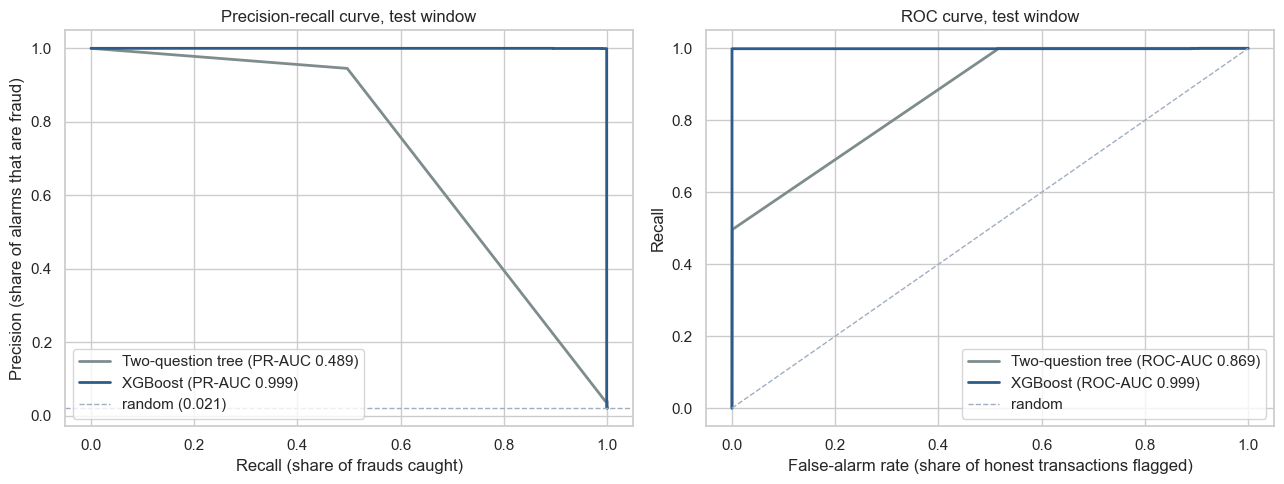

In [32]:
tree_scores = tree.predict_proba(X_test[tree_cols].fillna(0))[:, 1]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, scores, color in [("Two-question tree", tree_scores, "#7f8c8d"), ("XGBoost", xgb_scores, "#2e5c8a")]:
    precision, recall, _ = precision_recall_curve(y_test, scores)
    axes[0].plot(recall, precision, color=color, lw=2, label=f"{name} (PR-AUC {average_precision_score(y_test, scores):.3f})")
    fpr, tpr, _ = roc_curve(y_test, scores)
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f"{name} (ROC-AUC {roc_auc_score(y_test, scores):.3f})")
axes[0].axhline(y_test.mean(), color="#a0aec0", ls="--", lw=1, label=f"random ({y_test.mean():.3f})")
axes[0].set_xlabel("Recall (share of frauds caught)")
axes[0].set_ylabel("Precision (share of alarms that are fraud)")
axes[0].set_title("Precision-recall curve, test window")
axes[0].legend(loc="lower left")
axes[1].plot([0, 1], [0, 1], color="#a0aec0", ls="--", lw=1, label="random")
axes[1].set_xlabel("False-alarm rate (share of honest transactions flagged)")
axes[1].set_ylabel("Recall")
axes[1].set_title("ROC curve, test window")
axes[1].legend(loc="lower right")
plt.tight_layout()
plt.savefig("figs/pr_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

XGBoost's precision-recall curve hugs the top-right corner: it can catch nearly all the fraud before precision
falls. The tree's curve drops at half recall, where its two questions run out. The ROC curves of both look
almost perfect, which is why ROC-AUC is reported but not used to choose anything.

---
## 9. Choosing the cut-off

A score is not a decision. Somebody has to pick the cut-off above which a transaction is frozen, and that is a
business choice about the cost of each kind of mistake.

**Step 9.1:** One common policy: catch as much fraud as possible while keeping precision at 99% or better. Find
that cut-off and look at the confusion matrix there.

cut-off: 0.3602   precision 0.9903   recall 0.9989


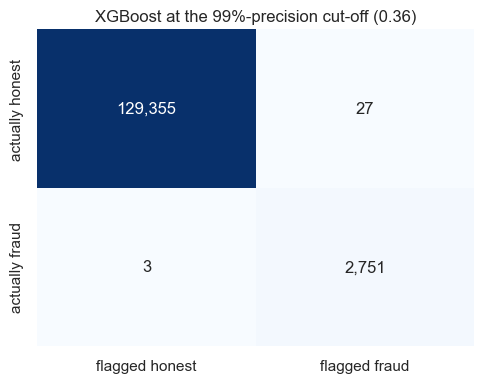

recall:    99.9%   precision: 99.0%


In [33]:
precision, recall, thresholds = precision_recall_curve(y_test, xgb_scores)
eligible = precision[:-1] >= 0.99
best = int(eligible.nonzero()[0][recall[:-1][eligible].argmax()])
operating_threshold = float(thresholds[best])

flags = (xgb_scores >= operating_threshold).astype(int)
print(f"cut-off: {operating_threshold:.4f}   precision {precision[best]:.4f}   recall {recall[best]:.4f}")
cm = show_confusion(y_test, flags, f"XGBoost at the 99%-precision cut-off ({operating_threshold:.2f})")

At this cut-off the model misses 3 frauds and raises 27 false alarms among about 129,000 honest test
transactions.

**Step 9.2:** A second policy weighs the two mistakes directly. Suppose a missed fraud costs 10 times as much as
a false alarm (`COST_RATIO`). Try every cut-off and keep the cheapest.

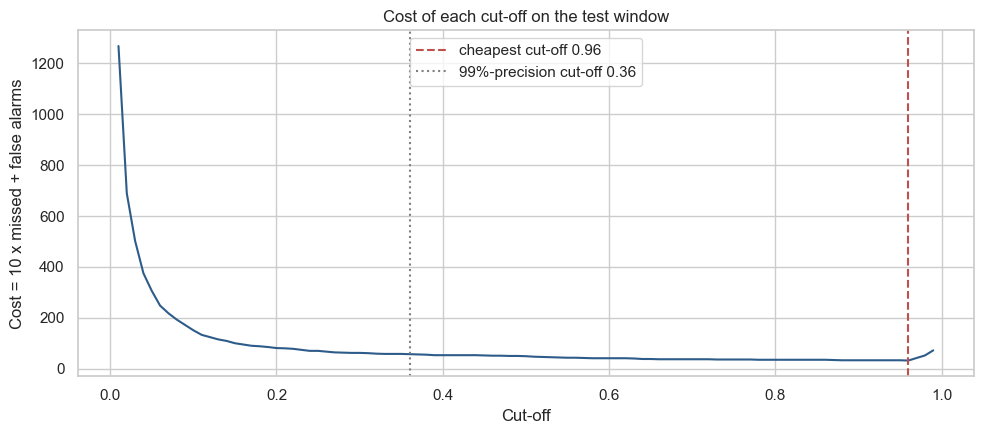

cheapest cut-off 0.96: 3 missed, 2 false alarms


In [34]:
cutoffs = np.linspace(0.01, 0.99, 99)
missed = np.array([int(((xgb_scores < c) & (y_test == 1)).sum()) for c in cutoffs])
false_alarms = np.array([int(((xgb_scores >= c) & (y_test == 0)).sum()) for c in cutoffs])
cost = COST_RATIO * missed + false_alarms
cheapest = int(cost.argmin())

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(cutoffs, cost, color="#2e5c8a")
ax.axvline(cutoffs[cheapest], color="#c0504d", linestyle="--", label=f"cheapest cut-off {cutoffs[cheapest]:.2f}")
ax.axvline(operating_threshold, color="gray", linestyle=":", label=f"99%-precision cut-off {operating_threshold:.2f}")
ax.set_xlabel("Cut-off")
ax.set_ylabel(f"Cost = {COST_RATIO} x missed + false alarms")
ax.set_title("Cost of each cut-off on the test window")
ax.legend()
plt.tight_layout()
plt.savefig("figs/cost_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"cheapest cut-off {cutoffs[cheapest]:.2f}: {missed[cheapest]} missed, {false_alarms[cheapest]} false alarms")

The two policies pick different cut-offs, and neither is "correct": the cost ratio has to come from the
business that will run the model. (The shipped pipeline assumes 100 to 1.)

> **Try it:** set `COST_RATIO = 100` in the settings cell, rerun it and Step 9.2. Where does the cheapest
> cut-off move, and why?

### 9.1 What precision really means in use

The test window is unusually fraud-heavy: about 2.1% of its transactions are fraud, against about 0.3% of all
TRANSFER and CASH_OUT transactions across the whole month (the only types the model screens). Precision depends
on that mix. If fraud is rarer, the same model meets more honest transactions per fraud, so the same
false-alarm *rate* produces more false alarms per real one.

**Step 9.3:** Take the model's two rates from the test window (the share of frauds it catches, and the share of
honest transactions it wrongly flags) and apply them to a million screened transactions at the whole-month
fraud rate.

In [35]:
catch_rate = cm[1, 1] / cm[1].sum()            # share of frauds flagged
false_alarm_rate = cm[0, 1] / cm[0].sum()      # share of honest transactions flagged
real_fraud_rate = target.mean()                # TRANSFER and CASH_OUT over the whole month, about 0.3%

frauds_per_million = 1_000_000 * real_fraud_rate
caught_per_million = catch_rate * frauds_per_million
false_alarms_per_million = false_alarm_rate * (1_000_000 - frauds_per_million)
precision_at_real_rate = caught_per_million / (caught_per_million + false_alarms_per_million)
print(f"per million transactions: {frauds_per_million:,.0f} frauds, {caught_per_million:,.0f} caught, {false_alarms_per_million:,.0f} false alarms")
print(f"precision at the real fraud rate: {precision_at_real_rate:.1%}  (on the test window: {precision[best]:.1%})")

per million transactions: 2,965 frauds, 2,961 caught, 208 false alarms
precision at the real fraud rate: 93.4%  (on the test window: 99.0%)


At the whole-month fraud rate, roughly one alarm in fifteen would be a false one, not one in a hundred.
Nothing about the model changed; only the mix of transactions did. An operations team sizing its review queue
needs this number, not the test-window precision. The shipped pipeline reports the same calculation for its own
model (`precision_at_real_fraud_rate` in `dashboard/data/business_impact.json`).

---
## 10. Comparing other model families

Is XGBoost special, or would other models do as well? Three more are trained, all scored by the same function.

**Step 10.1:** Logistic regression, a linear model. It cannot take missing values, so the sender-side `NaN`s
are filled with 1 (a value that cannot be confused with a real balance or with the -1 marker), and every input
is rescaled to a similar range.

In [36]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

logistic = Pipeline([
    ("fill", SimpleImputer(strategy="constant", fill_value=1)),
    ("scale", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)),
])
logistic.fit(X_train, y_train)
score_model("Logistic regression", logistic.predict_proba(X_test)[:, 1])

Logistic regression                PR-AUC 0.7901   recall at 99% precision 0.4503


**Step 10.2:** A random forest: hundreds of deep trees, each trained on a random sample, voting together.

In [37]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=200, max_depth=16, min_samples_leaf=20,
                                class_weight="balanced_subsample", n_jobs=RF_JOBS, random_state=SEED)
forest.fit(X_train, y_train)
score_model("Random forest", forest.predict_proba(X_test)[:, 1])

Random forest                      PR-AUC 1.0000   recall at 99% precision 1.0000


**Step 10.3:** LightGBM, another gradient-boosting library, with the same class weight and larger trees.

In [38]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(n_estimators=400, num_leaves=31, learning_rate=0.05, min_child_samples=5,
                      scale_pos_weight=class_weight, n_jobs=N_JOBS, random_state=SEED, verbose=-1)
lgbm.fit(X_train, y_train)
score_model("LightGBM", lgbm.predict_proba(X_test)[:, 1])

LightGBM                           PR-AUC 0.0338   recall at 99% precision 0.0000


**Step 10.4:** Put them side by side.

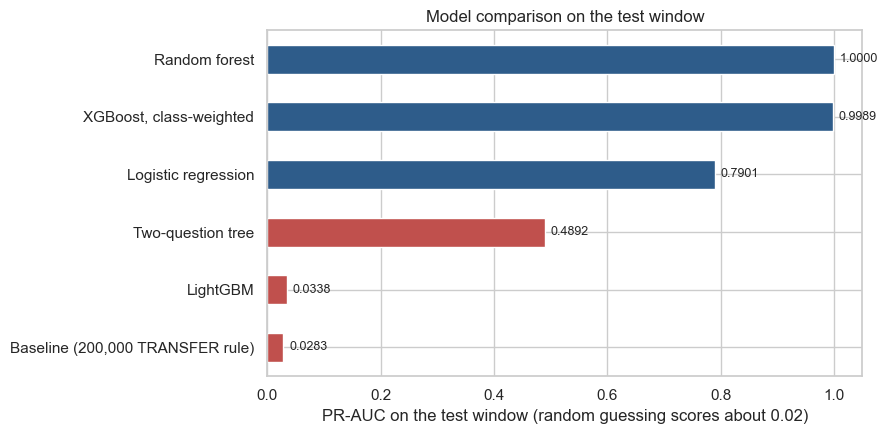

                                  PR-AUC  ROC-AUC  Recall at 99% precision
Random forest                     1.0000   1.0000                   1.0000
XGBoost, class-weighted           0.9989   0.9990                   0.9989
Logistic regression               0.7901   0.9795                   0.4503
Two-question tree                 0.4892   0.8694                   0.0000
LightGBM                          0.0338   0.6956                   0.0000
Baseline (200,000 TRANSFER rule)  0.0283   0.5888                   0.0000


In [39]:
scoreboard = pd.DataFrame(results).T.sort_values("PR-AUC", ascending=False)
fig, ax = plt.subplots(figsize=(9, 4.5))
scoreboard["PR-AUC"].sort_values().plot(kind="barh", ax=ax,
                                        color=["#c0504d" if v < 0.5 else "#2e5c8a" for v in scoreboard["PR-AUC"].sort_values()])
ax.set_xlabel("PR-AUC on the test window (random guessing scores about 0.02)")
ax.set_title("Model comparison on the test window")
ax.set_xlim(0, 1.05)
for i, v in enumerate(scoreboard["PR-AUC"].sort_values()):
    ax.text(v + 0.01, i, f"{v:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("figs/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(scoreboard.to_string(float_format=lambda v: f"{v:.4f}"))

Three lessons are in this table.

1. **A perfect score is a warning, not a win.** The random forest reaches PR-AUC 1.0000. Real fraud is never
   this separable. PaySim generates fraud by a simple process, and once the error features exist the label
   follows from them almost exactly. On a simulator, the scores show that the method works; they do not tell
   you how accurate a model would be on a real network.
2. **Models can fail quietly.** LightGBM, with deep trees, few rows per leaf and a large class weight, falls to
   about 0.03, no better than the 200,000 rule, without any error message. Remember the test window has ten
   times the fraud rate of training (section 5); a model tuned too tightly to the training window can break on
   a shift like that. Always score on later data before trusting a model.
3. **A linear model is not enough here.** Logistic regression ranks well overall but cannot keep 99% precision
   while catching most fraud, most likely because the fraud pattern ("this error is zero *and* that one is
   not") is a combination that a linear model cannot express directly.

---
## 11. Does it hold up over time?

A single test score hides change over time. Split the test window into four periods and score XGBoost on
each, keeping the cut-off chosen in Step 9.1 fixed, as it would be in use.

**Step 11.1:** Score each period.

In [40]:
test_steps = features.loc[~train_mask, "step"].to_numpy()
period_rows = []
for start, end in [(491, 560), (561, 630), (631, 700), (701, 743)]:
    in_period = (test_steps >= start) & (test_steps <= end)
    truth, scores = y_test.to_numpy()[in_period], xgb_scores[in_period]
    flagged_period = scores >= operating_threshold
    period_rows.append({"hours": f"{start}-{end}", "transactions": int(in_period.sum()), "frauds": int(truth.sum()),
                        "PR-AUC": average_precision_score(truth, scores),
                        "precision": (flagged_period & (truth == 1)).sum() / max(flagged_period.sum(), 1),
                        "recall": (flagged_period & (truth == 1)).sum() / truth.sum()})
periods = pd.DataFrame(period_rows).set_index("hours")
print(periods.to_string(float_format=lambda v: f"{v:.4f}"))

         transactions  frauds  PR-AUC  precision  recall
hours                                                   
491-560         50526     726  1.0000     0.9878  1.0000
561-630         43619     764  0.9986     0.9858  0.9987
631-700         32774     774  0.9975     0.9910  0.9974
701-743          5217     490  1.0000     1.0000  1.0000


**Step 11.2:** Plot the three measures by period.

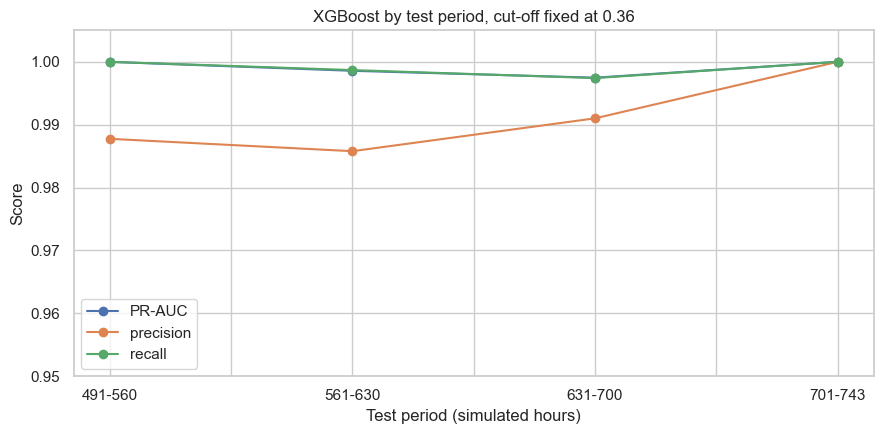

In [41]:
fig, ax = plt.subplots(figsize=(9, 4.5))
periods[["PR-AUC", "precision", "recall"]].plot(marker="o", ax=ax)
ax.set_ylim(0.95, 1.005)
ax.set_xlabel("Test period (simulated hours)")
ax.set_ylabel("Score")
ax.set_title(f"XGBoost by test period, cut-off fixed at {operating_threshold:.2f}")
ax.legend(loc="lower left")
plt.tight_layout()
plt.savefig("figs/performance_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

Ranking (PR-AUC) and recall stay close to perfect in every period, and precision stays between about 98.6% and
100% at the fixed cut-off, even though the mix shifts sharply: the last period has a tenth of the transactions
of the first, and nearly one in ten of them is fraud. On real data this check would be run every week, and a
fall in precision or recall would trigger a review of the cut-off or a retrain. The shipped pipeline does a
stricter version (`src/validate.py` retrains on expanding windows; `src/monitoring.py` tracks how the inputs
drift).

---
## 12. Is resampling better than class weights?

A common textbook alternative to class weights is SMOTE: create synthetic frauds by drawing points between real
frauds until the classes are balanced. One worry for time-ordered data is that it mixes frauds from different
periods.

**Step 12.1:** Resample the training data with SMOTE and train the same XGBoost on it, with no class weight
(the classes are now balanced). SMOTE cannot handle missing values, so they are filled with -1 first.

In [42]:
from imblearn.over_sampling import SMOTE

X_train_filled, X_test_filled = X_train.fillna(-1), X_test.fillna(-1)
X_smote, y_smote = SMOTE(random_state=SEED, k_neighbors=5).fit_resample(X_train_filled, y_train)
print(f"training rows: {len(X_train_filled):,} -> {len(X_smote):,}; frauds: {int(y_train.sum()):,} -> {int(y_smote.sum()):,}")

smote_model = XGBClassifier(max_depth=3, scale_pos_weight=1, n_jobs=N_JOBS).fit(X_smote, y_smote)
score_model("XGBoost + SMOTE", smote_model.predict_proba(X_test_filled)[:, 1])
del X_smote, y_smote, X_train_filled, X_test_filled

training rows: 2,638,273 -> 5,265,628; frauds: 5,459 -> 2,632,814


XGBoost + SMOTE                    PR-AUC 0.9995   recall at 99% precision 0.9949


SMOTE scores 0.9995 against 0.9989 for class weighting, a difference of 0.06 points, and it doubled the training
data to get there. On this data the two approaches are equivalent; class weights are the cheaper choice. (The
comparison also changed how missing values are handled, so it does not settle the question in general.)

---
## 13. Explaining decisions

If a customer's money is frozen, someone has to say why. **SHAP** splits a model's score for one transaction
into a contribution from each input, measured against an average transaction: positive values push towards
fraud, negative towards honest.

**Step 13.1:** Explain the highest-scoring fraud in the test window and one ordinary honest transfer.

In [43]:
warnings.filterwarnings("ignore", message="IProgress not found")   # SHAP's progress bar, not the analysis
import shap

explainer = shap.TreeExplainer(model)
fraud_row = X_test[y_test == 1].iloc[[int(np.argmax(xgb_scores[(y_test == 1).to_numpy()]))]]
honest_row = X_test[(y_test == 0) & (X_test["type"] == 0)].iloc[[0]]

for label, row in [("fraud", fraud_row), ("honest", honest_row)]:
    contributions = pd.Series(explainer.shap_values(row)[0], index=MODEL_COLS)
    top = contributions.reindex(contributions.abs().sort_values(ascending=False).index)[:3]
    print(f"{label} transaction, score {model.predict_proba(row)[0, 1]:.4f}; largest pushes:")
    for name, value in top.items():
        print(f"   {name:18s} value {row[name].iloc[0]:>14,.2f}   push {value:+.2f}")

fraud transaction, score 1.0000; largest pushes:
   newBalanceDest     value          -1.00   push +35.86
   oldBalanceOrig     value     449,199.47   push +20.23
   errorBalanceOrig   value           0.00   push +19.30
honest transaction, score 0.0000; largest pushes:
   errorBalanceOrig   value     834,162.12   push -15.63
   amount             value     954,064.12   push +3.15
   oldBalanceOrig     value     119,902.00   push -1.70


**Step 13.2:** Compute SHAP values for 2,000 test transactions and draw the summary plot: one row per input,
one dot per transaction, coloured by the input's value, placed by how far it pushed the score.

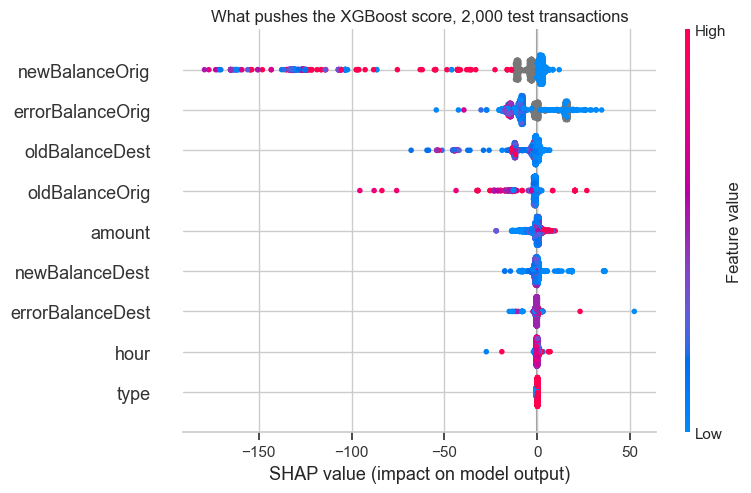

mean |SHAP| by input:
newBalanceOrig     16.01
errorBalanceOrig   10.26
oldBalanceDest      4.50
oldBalanceOrig      3.12
amount              2.07
newBalanceDest      1.61
errorBalanceDest    0.62
hour                0.48
type                0.15


In [44]:
shap_sample = X_test.sample(2_000, random_state=SEED)
shap_values = explainer.shap_values(shap_sample)
shap.summary_plot(shap_values, shap_sample, show=False, max_display=9)
plt.title("What pushes the XGBoost score, 2,000 test transactions")
plt.tight_layout()
plt.savefig("figs/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

importance = pd.Series(np.abs(shap_values).mean(axis=0), index=MODEL_COLS).sort_values(ascending=False)
print("mean |SHAP| by input:")
print(importance.round(3).to_string())

The sender-side error feature is near the top, as the ledger reasoning predicted, but the raw sender balance
matters most. That is a warning sign: in PaySim almost every fraud empties the sender's account (section 3.7),
so "the balance went to zero" works as a shortcut. It would also flag an honest customer closing their own
account. The shipped pipeline removes the raw balances for this reason (section 15).

---
# Part 3: What it is worth

## 14. Business impact: fraud value stopped, honest customers frozen

A fraud-operations team needs two numbers from any screen: how much of the fraud value it stops, and how many
honest customers it freezes to do so. A fraud's value is its transaction amount; a frozen honest customer is a
false alarm. Both are counted on the test window, in the simulator's currency units.

**Step 14.1:** Count them for every screen seen so far: no screening, PaySim's built-in flag, the documented
200,000 rule, the two-question tree, and XGBoost at the two cut-offs from section 9.

In [45]:
amount_test = X_test["amount"].to_numpy()
truth = y_test.to_numpy() == 1
total_fraud_value = amount_test[truth].sum()


def screen_outcome(flagged):
    flagged = np.asarray(flagged).astype(bool)
    stopped = amount_test[flagged & truth].sum()
    return {"frauds caught": int((flagged & truth).sum()), "frauds missed": int((~flagged & truth).sum()),
            "fraud value stopped": stopped, "share of fraud value stopped": stopped / total_fraud_value,
            "honest customers frozen": int((flagged & ~truth).sum()), "honest value frozen": amount_test[flagged & ~truth].sum()}


screens = {
    "No screening": np.zeros(len(y_test), dtype=bool),
    "Built-in flag (isFlaggedFraud)": builtin_flag[~train_mask].to_numpy() == 1,
    "200,000 TRANSFER rule": rule.to_numpy() == 1,
    "Two-question tree": tree_flags == 1,
    f"XGBoost, 99%-precision cut-off ({operating_threshold:.2f})": xgb_scores >= operating_threshold,
    f"XGBoost, cheapest cut-off ({cutoffs[cheapest]:.2f})": xgb_scores >= cutoffs[cheapest],
}
impact = pd.DataFrame.from_dict({name: screen_outcome(flagged) for name, flagged in screens.items()}, orient="index")
print(f"test window: {len(y_test):,} transactions, {int(truth.sum()):,} frauds worth {total_fraud_value / 1e9:.2f} billion")
shown = impact.copy()
shown["share of fraud value stopped"] = shown["share of fraud value stopped"].map("{:.2%}".format)
shown

test window: 132,136 transactions, 2,754 frauds worth 4.19 billion


,frauds caught,frauds missed,fraud value stopped,share of fraud value stopped,honest customers frozen,honest value frozen
No screening,0,2754,0.00,0.00%,0,0.00
Built-in flag (isFlaggedFraud),10,2744,"46,474,810.66",1.11%,0,0.00
"200,000 TRANSFER rule",932,1822,"2,081,391,981.61",49.67%,20797,"19,571,928,624.88"
Two-question tree,1367,1387,"2,072,168,819.50",49.45%,79,"33,323,426.05"
"XGBoost, 99%-precision cut-off (0.36)",2751,3,"4,186,618,488.90",99.90%,27,"4,971,209.31"
"XGBoost, cheapest cut-off (0.96)",2751,3,"4,186,618,488.90",99.90%,2,"432,694.16"


In [46]:
# Check: the model stops more fraud value than the built-in flag, and no screen stops more than exists
assert impact.loc[f"XGBoost, 99%-precision cut-off ({operating_threshold:.2f})", "fraud value stopped"] > impact.loc["Built-in flag (isFlaggedFraud)", "fraud value stopped"]
assert (impact["share of fraud value stopped"] <= 1).all()

**Step 14.2:** Plot the share of fraud value stopped by each screen, with the honest customers frozen beside
it.

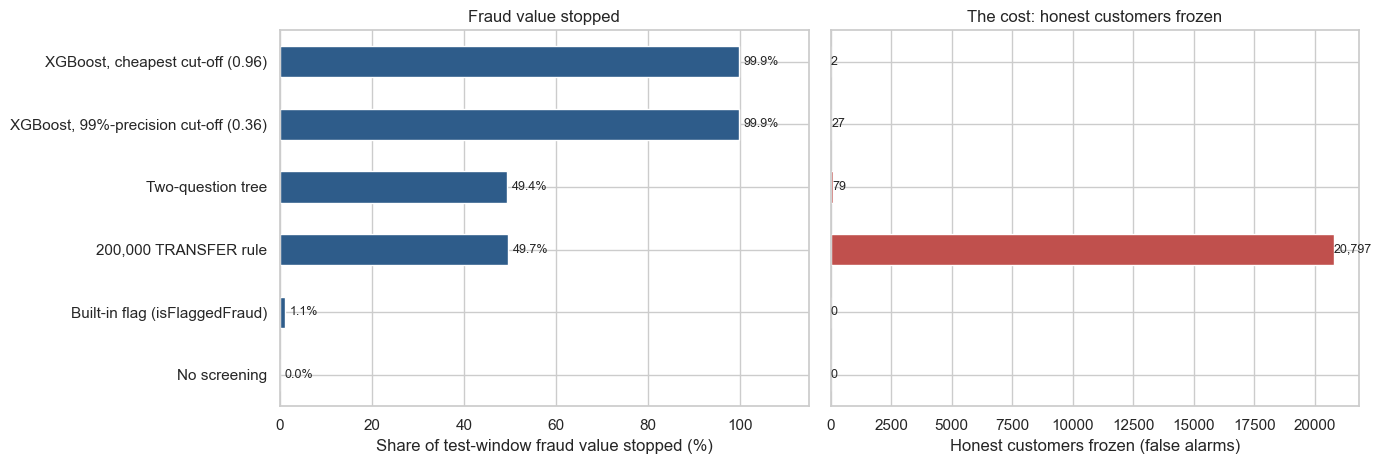

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
(impact["share of fraud value stopped"] * 100).plot(kind="barh", ax=axes[0], color="#2e5c8a")
axes[0].set_xlabel("Share of test-window fraud value stopped (%)")
axes[0].set_title("Fraud value stopped")
for i, v in enumerate(impact["share of fraud value stopped"] * 100):
    axes[0].text(v + 1, i, f"{v:.1f}%", va="center", fontsize=9)
axes[0].set_xlim(0, 115)
impact["honest customers frozen"].plot(kind="barh", ax=axes[1], color="#c0504d")
axes[1].set_xlabel("Honest customers frozen (false alarms)")
axes[1].set_title("The cost: honest customers frozen")
for i, v in enumerate(impact["honest customers frozen"]):
    axes[1].text(v + 2, i, f"{v:,}", va="center", fontsize=9)
axes[1].set_yticklabels([])
plt.tight_layout()
plt.savefig("figs/fraud_value_by_screen.png", dpi=150, bbox_inches="tight")
plt.show()

The built-in flag stops about 1% of the fraud value. The 200,000 rule and the two-question tree each stop
about half of it, but at very different prices: the rule freezes more than 20,000 honest customers to do so,
the tree 79. XGBoost at the 99%-precision cut-off stops 99.9% of the fraud value and freezes 27 honest
customers; at the cheapest cut-off it stops the same value and freezes 2. For a fraud team, this table is the
model: the score only matters through what it stops and what it costs.

---
# Part 4: Limits and record

## 15. From this notebook to the shipped model

This notebook is for learning, so it keeps things that the shipped pipeline in `src/` changes:

| | This notebook | Shipped pipeline (`src/`) |
|---|---|---|
| Inputs | 9, including the raw balances and the hour | 5: the amount, the two balance errors, and two ratios (how much of the sender's balance moved, and the amount against the recipient's balance) |
| Raw balances | Kept, to show what they do | Removed: the model used "balance hits zero" as a shortcut |
| Settings | Library defaults, class weight 482 | Tuned on earlier windows only (35 trees, class weight 2.14) |
| Probabilities | Raw model scores | Calibrated, so a score of 0.9 means about a 90% chance |
| Cut-off | 99% precision on the test window | Cheapest at a 100:1 cost ratio, chosen on calibration data before the test window |
| Over time | Four test periods, cut-off fixed | Four expanding retraining windows, plus input-drift monitoring |

The README and `docs/METHODOLOGY.md` report the shipped model's results; this notebook explains the ideas
behind it.

## 16. Limitations

- **PaySim is a simulator.** Once the error features exist, its fraud labels follow from them almost
  exactly, which is why a random forest reaches PR-AUC 1.0000 (section 10). The scores show that the
  evaluation method works; they say nothing about the accuracy to expect on a real network.
- **One fraud signature.** Almost every simulated fraud drains the sender's whole balance (section 3.7).
  Partial-skim fraud, where only part of a balance is taken, is not represented and would not be detected.
- **The raw balances are a shortcut.** The notebook keeps them to show what they do (section 13); a customer
  honestly closing their own account would be flagged. The shipped model removes them and only partly closes
  the gap (section 15).
- **The test window is fraud-heavy.** About 2.1% of its transactions are fraud against 0.3% across the month,
  because honest volume collapses in the last third of the simulation (section 3.4). Every precision figure
  depends on that mix, which is why section 9.1 restates it at the real rate.
- **The cut-off is chosen on the test window.** Sections 9 and 14 pick cut-offs on the same transactions they
  are then scored on, which is fine for teaching and not for deployment; the shipped pipeline chooses its
  cut-off on calibration data that precedes the test window.
- **Money figures are simulated units**, and the cost ratio of a missed fraud to a false alarm is an
  assumption, not a measurement.
- **No account history.** Because almost every account appears once (section 3.5), none of the features a real
  fraud team relies on (velocity, repeat recipients, device and location) can be built from this data.

---
## 17. Results file

Every headline number above is written to `outputs/notebook_results.json`, with the package versions, the git
commit of the code and the run time, so the README and `docs/METHODOLOGY.md` can be checked against it.

**Step 17.1:** Small helpers for the provenance record: a package's version, a git query, and the peak memory
used by this run.

In [48]:
import json
import platform
import subprocess
from datetime import datetime, timezone
from importlib.metadata import PackageNotFoundError, version


def package_version(name):
    try:
        return version(name)
    except PackageNotFoundError:
        return None


def git(*args):
    try:
        return subprocess.run(["git", *args], capture_output=True, text=True, check=True).stdout.strip()
    except Exception:
        return None


def peak_memory_gb():
    try:
        import psutil
        info = psutil.Process().memory_info()
        peak = getattr(info, "peak_wset", None)  # Windows
        if peak is None:
            import resource  # Linux and macOS
            peak = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss * 1024
        return round(peak / 1e9, 1)
    except Exception:
        return None

**Step 17.2:** Record where the numbers came from, then the data, split, model, cut-off, period, impact and
SHAP figures, and write the file.

In [49]:
uncommitted = git("status", "--porcelain", "--", ".", ":(exclude)*.ipynb", ":(exclude)figs", ":(exclude)outputs")

notebook_results = {
    "provenance": {
        "run_date_utc": datetime.now(timezone.utc).strftime("%Y-%m-%d"),
        "runtime_minutes": round((time.time() - RUN_STARTED) / 60),
        "peak_memory_gb": peak_memory_gb(),
        "git_commit": git("rev-parse", "HEAD"),
        "uncommitted_code_changes": None if uncommitted is None else bool(uncommitted),
        "python": platform.python_version(),
        "packages": {p: package_version(p) for p in (
            "numpy", "pandas", "scikit-learn", "xgboost", "lightgbm", "imbalanced-learn", "shap", "matplotlib", "seaborn")},
    },
    "data": {
        "transactions": 6_362_620,
        "frauds": n_fraud,
        "fraud_rate": n_fraud / 6_362_620,
        "by_type": by_type.reset_index().to_dict(orient="records"),
        "transfer_and_cash_out": int(len(features)),
        "builtin_flag_flagged": int(flagged.sum()),
        "builtin_flag_recall": caught / n_fraud,
        "balance_patterns_pct": (balance_patterns * 100).round(2).to_dict(),
    },
    "split": {
        "split_step": SPLIT_STEP,
        "train_rows": int(len(X_train)), "train_fraud_rate": float(y_train.mean()), "train_frauds": int(y_train.sum()),
        "test_rows": int(len(X_test)), "test_fraud_rate": float(y_test.mean()), "test_frauds": int(y_test.sum()),
        "class_weight": float(class_weight),
        "model_inputs": MODEL_COLS,
    },
    "models": {name: {k: float(v) for k, v in row.items()} for name, row in results.items()},
    "cut_off": {
        "precision_floor": 0.99,
        "operating_threshold": operating_threshold,
        "precision": float(precision[best]), "recall": float(recall[best]),
        "frauds_missed": int(cm[1, 0]), "false_alarms": int(cm[0, 1]),
        "cost_ratio": COST_RATIO, "cheapest_threshold": float(cutoffs[cheapest]),
        "cheapest_missed": int(missed[cheapest]), "cheapest_false_alarms": int(false_alarms[cheapest]),
        "real_fraud_rate": float(real_fraud_rate),
        "false_alarms_per_million_at_real_rate": float(false_alarms_per_million),
        "precision_at_real_fraud_rate": float(precision_at_real_rate),
    },
    "periods": periods.reset_index().to_dict(orient="records"),
    "impact": {"test_fraud_value": float(total_fraud_value), "screens": impact.to_dict(orient="index")},
    "shap_mean_abs": {k: float(v) for k, v in importance.items()},
}

with open("outputs/notebook_results.json", "w", encoding="utf-8") as f:
    json.dump(notebook_results, f, indent=2, default=lambda o: o.item() if hasattr(o, "item") else str(o))
print("Wrote outputs/notebook_results.json")
print(json.dumps(notebook_results["provenance"], indent=2))

Wrote outputs/notebook_results.json
{
  "run_date_utc": "2026-10-09",
  "runtime_minutes": 27,
  "peak_memory_gb": 4.3,
  "git_commit": "247873d6daa89e837f5b681c0b1db88a01cc2fed",
  "uncommitted_code_changes": true,
  "python": "3.13.9",
  "packages": {
    "numpy": "2.4.6",
    "pandas": "3.0.3",
    "scikit-learn": "1.8.0",
    "xgboost": "3.3.0",
    "lightgbm": "4.6.0",
    "imbalanced-learn": "0.14.2",
    "shap": "0.51.0",
    "matplotlib": "3.9.2",
    "seaborn": "0.13.2"
  }
}


## What you learned

- Accuracy hides rare events; recall, precision and PR-AUC do not (sections 3.2 and 7).
- Honest volume and fraud volume move independently, so the fraud rate a model meets changes over time
  (sections 3.4 and 5).
- A domain rule, here the accounting identity, can become the most useful feature (section 4).
- Split by time, keep the split variable out of the inputs, and score once on the future (section 5).
- Start with a model you can read; it sets a baseline and shows what the data is saying (section 6).
- The cut-off is a business decision, and precision must be restated at the real fraud rate (section 9).
- A perfect score on simulated data is a warning; a quiet collapse on later data is a reason to test on it
  (section 10).
- Check performance period by period, explain individual decisions, and report what a screen stops and what it
  costs (sections 11, 13 and 14).

**Exercises**

1. Remove `oldBalanceOrig` and `newBalanceOrig` from `MODEL_COLS`, rerun from Step 5.1, and compare XGBoost's
   PR-AUC and the SHAP chart with the version above.
2. Change `SPLIT_STEP` to 600. How do the training fraud rate and the test results change?
3. In Step 9.3, set `real_fraud_rate` to 0.005 and to 0.0005. How does precision move, and what does that mean
   for a team that can review 50 alerts a day?

## Glossary

- **Precision / recall:** of the alarms raised, the share that are fraud / of the frauds, the share caught.
- **PR-AUC (average precision):** one number summarising precision and recall over every cut-off; random
  guessing scores the fraud rate.
- **ROC-AUC:** the chance a random fraud scores above a random honest transaction; looks high even for weak
  fraud models because honest transactions are so many.
- **Class weight:** how much more a mistake on the rare class counts during training.
- **Cut-off (threshold):** the score above which a transaction is flagged.
- **SMOTE:** a resampling method that creates synthetic examples of the rare class.
- **SHAP value:** one input's contribution to one prediction, against an average prediction.